# 04 — Report figures and tables

Nothing is recomputed here. This notebook reads the outputs of 01–03 and produces exactly what the report needs:

* six figures in `figures/report/`, sized for a two-column page, 300 dpi
* LaTeX tables in `report/tables/`, `\input`-ed by `main.tex`, so a rerun updates the report
* one appendix workbook, `outputs/report/appendix_tables.xlsx`

**Figure budget.** Five and a half pages carry about six figures. Four go in the methodology and data-quality sections (each one is evidence for a decision), two in the results. The candidates left out are listed at the end with the reason.

In [1]:
# --- config ---
from pathlib import Path
import sys, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
OUT = ROOT / "outputs"
REPORT = ROOT / "report"; TABLES = REPORT / "tables"
FIG = ROOT / "figures" / "report"
RES = OUT / "report"
for d in (FIG, TABLES, RES): d.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "src"))

SAVE = True
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
                     "font.size": 8, "axes.titlesize": 9, "legend.fontsize": 7,
                     "axes.grid": True, "grid.alpha": .3})
W1, W2 = 3.4, 7.0        # single- and double-column widths, inches

# --- inputs from 01-03 ---
g_spots = pd.read_csv(OUT / "glass" / "glass_spots_flagged.csv")
g_avg   = pd.read_csv(OUT / "glass" / "glass_sample_averages.csv")
g_acc   = pd.read_csv(OUT / "glass" / "glass_accuracy.csv")
g_prec  = pd.read_csv(OUT / "glass" / "glass_precision.csv")
o_spots = pd.read_csv(OUT / "olivine" / "olivine_spots_flagged.csv")
o_avg   = pd.read_csv(OUT / "olivine" / "olivine_grain_averages.csv")
o_acc   = pd.read_csv(OUT / "olivine" / "olivine_accuracy.csv", index_col=0)
o_prec  = pd.read_csv(OUT / "olivine" / "olivine_precision.csv", index_col=0)
o_zone  = pd.read_csv(OUT / "olivine" / "olivine_zoning.csv", index_col=0)
la_tr   = pd.read_csv(OUT / "laicpms" / "la_inclusions_traces.csv", index_col=0)
la_pa   = pd.read_csv(OUT / "laicpms" / "la_precision_accuracy.csv", index_col=0)
la_rep  = pd.read_csv(OUT / "laicpms" / "la_reportability.csv", index_col=0)
la_ox   = pd.read_csv(OUT / "laicpms" / "la_major_oxides_normalised.csv", index_col=0)
chond   = pd.read_csv(OUT / "interim" / "la_chondrite.csv", index_col=0)
la_idx  = pd.read_csv(OUT / "interim" / "la_index.csv").set_index("label")

REE = ["La139", "Ce140", "Pr141", "Nd146", "Sm147", "Eu151", "Gd157", "Tb159",
       "Dy163", "Ho165", "Er166", "Tm169", "Yb172", "Lu175"]
REE_LAB = [e.rstrip("0123456789") for e in REE]
print("loaded:", len(g_spots), "glass spots |", len(o_spots), "olivine spots |", len(la_tr), "inclusions")

loaded: 81 glass spots | 113 olivine spots | 47 inclusions


## Figure 1 — drift, and why the two EPMA sessions were treated differently

The single most useful methodology figure: the same kind of plot for both sessions, showing why one was corrected and the other was not.

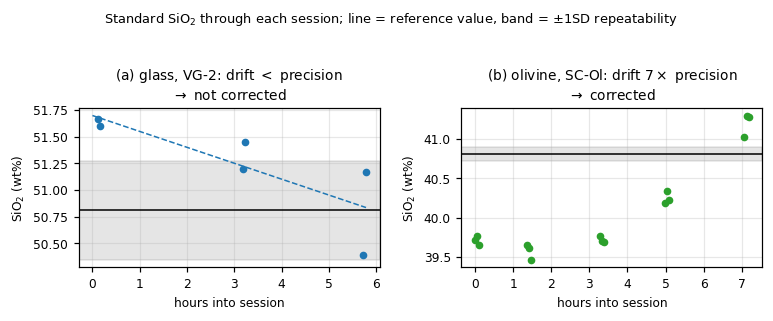

In [2]:
gm = pd.read_csv(OUT / "interim" / "glass_meta.csv", parse_dates=["datetime"])
om = pd.read_csv(OUT / "interim" / "ol_meta.csv", parse_dates=["datetime"])
gl = pd.read_csv(OUT / "interim" / "glass_oxide.csv").merge(gm[["No.", "datetime"]], on="No.")
ol = pd.read_csv(OUT / "interim" / "ol_oxide.csv").merge(om[["No.", "datetime"]], on="No.")
gl["h"] = (gl.datetime - gl.datetime.min()).dt.total_seconds() / 3600
ol["h"] = (ol.datetime - ol.datetime.min()).dt.total_seconds() / 3600

fig, axs = plt.subplots(1, 2, figsize=(W2, 2.9))

d = gl[gl.material == "VG2"]
ax = axs[0]
ax.plot(d.h, d.SiO2, "o", ms=4, color="tab:blue")
ax.axhline(50.81, color="k", lw=1)
ax.axhspan(50.81 - d.SiO2.std(), 50.81 + d.SiO2.std(), color="k", alpha=.10)
b, a = np.polyfit(d.h, d.SiO2, 1); xs = np.linspace(0, d.h.max(), 5)
ax.plot(xs, b * xs + a, "--", color="tab:blue", lw=1)
ax.set(xlabel="hours into session", ylabel="SiO$_2$ (wt%)",
       title="(a) glass, VG-2: drift $<$ precision\n$\\rightarrow$ not corrected")

d = ol[ol.is_std]
ax = axs[1]
ax.plot(d.h, d.SiO2, "o", ms=4, color="tab:green")
ax.axhline(40.81, color="k", lw=1)
w = (2 * d.groupby(pd.cut(d.h, 5)).SiO2.std()).mean() / 2
ax.axhspan(40.81 - w, 40.81 + w, color="k", alpha=.10)
ax.set(xlabel="hours into session", ylabel="SiO$_2$ (wt%)",
       title="(b) olivine, SC-Ol: drift $7\\times$ precision\n$\\rightarrow$ corrected")

fig.suptitle("Standard SiO$_2$ through each session; line = reference value, band = $\\pm$1SD repeatability",
             fontsize=8.5)
fig.tight_layout(rect=(0, 0, 1, 0.94))
if SAVE: fig.savefig(FIG / "fig1_drift.png")


## Figure 2 — accuracy against precision, all three techniques

The figure that carries the whole data-quality section: points above the 1:1 line deviate from their reference value by more than the measurement can explain.

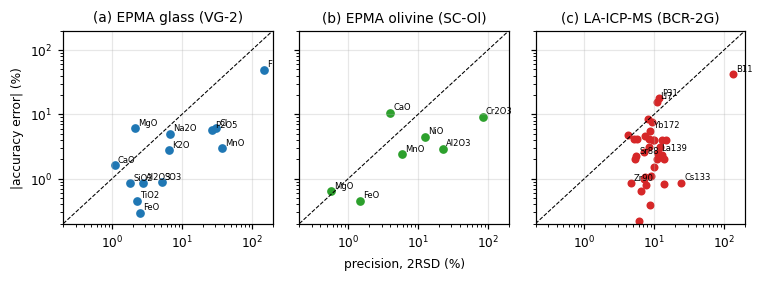

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(W2, 2.6), sharex=True, sharey=True)

d = g_acc[(g_acc.standard == "VG2") & g_acc.reference.notna()].copy()
d["prec"] = 100 * d.sd2 / d.measured
axs[0].scatter(d.prec, d.dev_pct.abs(), s=22, color="tab:blue")
for _, r in d.iterrows():
    axs[0].annotate(r.oxide, (r.prec, abs(r.dev_pct)), fontsize=5.5, xytext=(2, 2), textcoords="offset points")
axs[0].set(title="(a) EPMA glass (VG-2)", ylabel="|accuracy error| (%)")

d = o_acc.copy(); d["prec"] = 100 * d["2SD"] / d.measured_corr
axs[1].scatter(d.prec, d.dev_pct_corr.abs(), s=22, color="tab:green")
for ox, r in d.iterrows():
    axs[1].annotate(ox, (r.prec, abs(r.dev_pct_corr)), fontsize=5.5, xytext=(2, 2), textcoords="offset points")
axs[1].set(title="(b) EPMA olivine (SC-Ol)", xlabel="precision, 2RSD (%)")

d = la_pa.dropna(subset=["BCR2G_dev_%"])
axs[2].scatter(d["KL2_2RSD_%"], d["BCR2G_dev_%"].abs(), s=18, color="tab:red")
for el in ["B11", "P31", "Li7", "Cs133", "La139", "Yb172", "Zr90", "Sr88"]:
    if el in d.index:
        axs[2].annotate(el, (d.loc[el, "KL2_2RSD_%"], abs(d.loc[el, "BCR2G_dev_%"])),
                        fontsize=5.5, xytext=(2, 2), textcoords="offset points")
axs[2].set(title="(c) LA-ICP-MS (BCR-2G)")

for ax in axs:
    ax.plot([0.2, 200], [0.2, 200], "k--", lw=.7)
    ax.set(xscale="log", yscale="log", xlim=(0.2, 200), ylim=(0.2, 200))
fig.tight_layout()
if SAVE: fig.savefig(FIG / "fig2_accuracy_precision.png")


## Figure 3 — closure tests and sample screening

One figure covering every screening decision that removed or split data: EPMA totals for both probe sessions, the LA-ICP-MS internal-standard test, and the two glass populations. The clinopyroxene spot is not plotted — three numbers describe it better than a panel would.

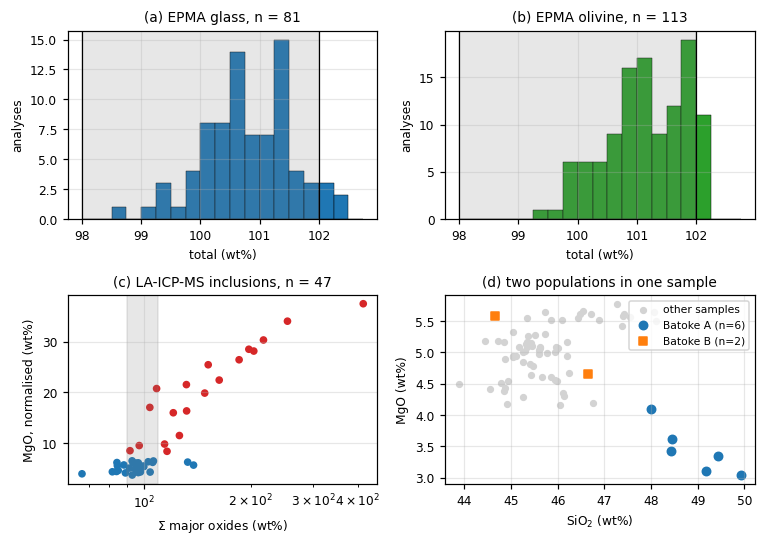

clinopyroxene spot (described in text, not plotted): No. 49, Al2O3 6.4, CaO 23.3, K2O 0.00 wt%


In [4]:
fig, axs = plt.subplots(2, 2, figsize=(W2, 5.0))

axs[0, 0].hist(g_spots.Total, bins=np.arange(98, 103, .25), color="tab:blue", edgecolor="k", lw=.3)
axs[0, 0].set(xlabel="total (wt%)", ylabel="analyses", title="(a) EPMA glass, n = %d" % len(g_spots))
axs[0, 1].hist(o_spots.Total, bins=np.arange(98, 103, .25), color="tab:green", edgecolor="k", lw=.3)
axs[0, 1].set(xlabel="total (wt%)", ylabel="analyses", title="(b) EPMA olivine, n = %d" % len(o_spots))
for ax in axs[0]:
    ax.axvspan(98, 102, color="tab:grey", alpha=.18)
    for x in (98, 102): ax.axvline(x, color="k", lw=.8)

ax = axs[1, 0]
ax.scatter(la_ox.loc[la_tr.index, "sum"], la_ox.loc[la_tr.index, "MgO"], s=16,
           c=np.where(la_tr.host_contaminated, "tab:red", "tab:blue"))
ax.axvspan(90, 110, color="tab:grey", alpha=.18)
ax.set(xscale="log", xlabel="$\\Sigma$ major oxides (wt%)", ylabel="MgO, normalised (wt%)",
       title="(c) LA-ICP-MS inclusions, n = %d" % len(la_tr))

ax = axs[1, 1]
bat = g_spots[(g_spots["sample"] == "UnknA-BatokeCS1-3") & g_spots.keep]
oth = g_spots[(g_spots["sample"] != "UnknA-BatokeCS1-3") & g_spots.keep]
ax.scatter(oth.SiO2, oth.MgO, s=14, c="lightgrey", label="other samples")
grp = bat.MgO > 4.2
ax.scatter(bat.SiO2[~grp], bat.MgO[~grp], s=30, c="tab:blue", label="Batoke A (n=%d)" % (~grp).sum())
ax.scatter(bat.SiO2[grp], bat.MgO[grp], s=30, c="tab:orange", marker="s", label="Batoke B (n=%d)" % grp.sum())
cpx = g_spots[g_spots.fail_crystal]
ax.set(xlabel="SiO$_2$ (wt%)", ylabel="MgO (wt%)", title="(d) two populations in one sample")
ax.legend(loc="upper right")
fig.tight_layout()
if SAVE: fig.savefig(FIG / "fig3_screening.png")
plt.show()
print("clinopyroxene spot (described in text, not plotted): No. %d, Al2O3 %.1f, CaO %.1f, K2O %.2f wt%%"
      % (cpx["No."].iloc[0], cpx.Al2O3.iloc[0], cpx.CaO.iloc[0], cpx.K2O.iloc[0]))

## Figure 4 — the glasses and the olivines

First results figure: Harker diagrams for the glasses and Fo–minor-element systematics for the olivines, both with 2SE error bars.

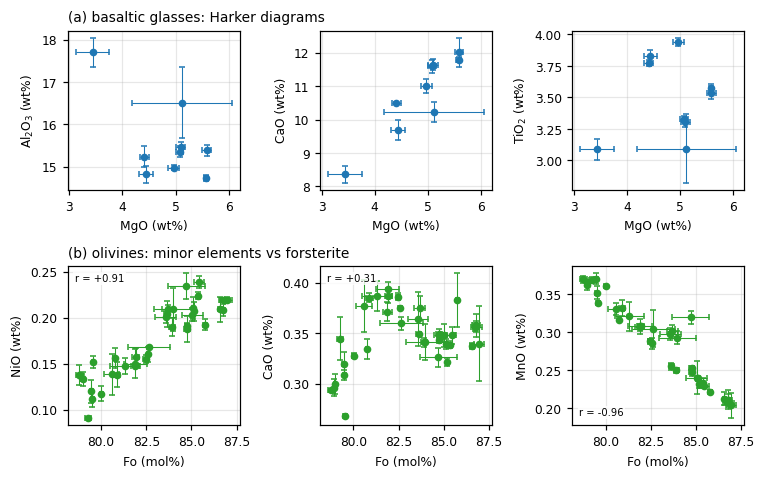

In [5]:
piv = lambda df, key, v: df.pivot(index=key, columns="oxide", values=v)
gm_, gs_ = piv(g_avg, "group", "mean"), piv(g_avg, "group", "2SE")
om_, os_ = piv(o_avg, "sample", "mean"), piv(o_avg, "sample", "2SE")
LBL = {"SiO2": "SiO$_2$", "TiO2": "TiO$_2$", "Al2O3": "Al$_2$O$_3$", "CaO": "CaO",
       "NiO": "NiO", "MnO": "MnO", "MgO": "MgO", "Na2O": "Na$_2$O", "K2O": "K$_2$O"}

fig, axs = plt.subplots(2, 3, figsize=(W2, 4.4))
for ax, ox in zip(axs[0], ["Al2O3", "CaO", "TiO2"]):
    ax.errorbar(gm_.MgO, gm_[ox], xerr=gs_.MgO, yerr=gs_[ox], fmt="o", ms=4, lw=.7, capsize=2, color="tab:blue")
    ax.set(xlabel="MgO (wt%)", ylabel=f"{LBL[ox]} (wt%)")
axs[0, 0].set_title("(a) basaltic glasses: Harker diagrams", loc="left")

for ax, ox in zip(axs[1], ["NiO", "CaO", "MnO"]):
    ax.errorbar(om_.Fo, om_[ox], xerr=os_.Fo, yerr=os_[ox], fmt="o", ms=4, lw=.7, capsize=2, color="tab:green")
    r = np.corrcoef(om_.Fo, om_[ox])[0, 1]
    ax.set(xlabel="Fo (mol%)", ylabel=f"{LBL[ox]} (wt%)")
    ax.text(.04, .06 if r < 0 else .9, f"r = {r:+.2f}", transform=ax.transAxes, fontsize=6.5,
            bbox=dict(fc="white", ec="none", alpha=.8, pad=1))
axs[1, 0].set_title("(b) olivines: minor elements vs forsterite", loc="left")
fig.tight_layout()
if SAVE: fig.savefig(FIG / "fig4_epma_geochemistry.png")
plt.show()

## Figure 5 — melt-inclusion trace elements

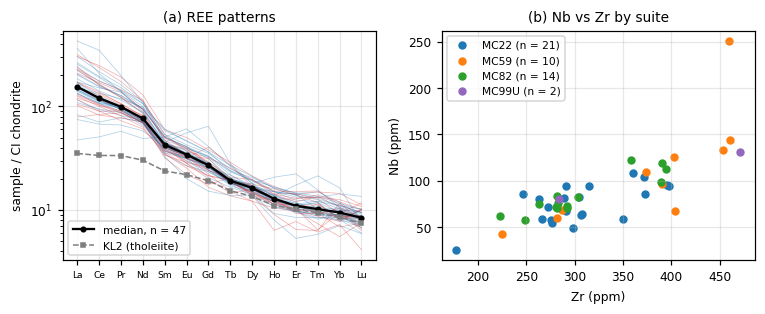

Nb/Zr: median 0.26, range 0.14-0.55


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(W2, 2.9))

ax = axs[0]
x = np.arange(len(REE))
for lab in la_tr.index:
    ax.plot(x, chond.loc[lab, REE], "-", lw=.5, alpha=.35,
            color="tab:red" if la_tr.loc[lab, "host_contaminated"] else "tab:blue")
ax.plot(x, chond.loc[la_tr.index, REE].median(), "ko-", ms=3, lw=1.5, label="median, n = %d" % len(la_tr))
ax.plot(x, chond.loc[la_idx.index[la_idx.material == "KL2"], REE].median(), "s--", ms=3, lw=1,
        color="tab:grey", label="KL2 (tholeiite)")
ax.set(yscale="log", xticks=x, ylabel="sample / CI chondrite", title="(a) REE patterns")
ax.set_xticklabels(REE_LAB, fontsize=6)
ax.legend(loc="lower left")

ax = axs[1]
suite = la_tr["sample"].str.extract(r"^(MC\d+U?)")[0]
for s, c in zip(["MC22", "MC59", "MC82", "MC99U"], ["tab:blue", "tab:orange", "tab:green", "tab:purple"]):
    sel = suite == s
    ax.scatter(la_tr.Zr90[sel], la_tr.Nb93[sel], s=20, color=c, label=f"{s} (n = {sel.sum()})")
ax.set(xlabel="Zr (ppm)", ylabel="Nb (ppm)", title="(b) Nb vs Zr by suite")
ax.legend()
fig.tight_layout()
if SAVE: fig.savefig(FIG / "fig5_laicpms_geochemistry.png")
plt.show()

print("Nb/Zr: median %.2f, range %.2f-%.2f"
      % ((la_tr.Nb93 / la_tr.Zr90).median(), (la_tr.Nb93 / la_tr.Zr90).min(), (la_tr.Nb93 / la_tr.Zr90).max()))

**Left out of the report, with reasons:** the clinopyroxene panel (three numbers in the text do the job), the Q-test flag table (a sentence), the olivine contamination screen (it found nothing — one line), the KL2 drift series (the result is "flat", better as a number), the Sc–Si interference plot (appendix), and the EPMA-vs-LA 1:1 plot, which cannot be made at all because no sample was measured by both techniques.

## Tables

Written as LaTeX fragments so `main.tex` picks up any rerun of 01–03 without re-typing numbers.

In [7]:
def write_tex(name, body):
    (TABLES / name).write_text(body)
    print("wrote", name, "(%d lines)" % body.count("\n"))

def fmt(x, nd=2):
    return "--" if pd.isna(x) else f"{x:.{nd}f}"

# --- Table 1: analytical conditions ---
gcnd = pd.read_csv(OUT / "interim" / "glass_calib.csv")
ocnd = pd.read_csv(OUT / "interim" / "ol_calib.csv")
rows = [
    ("Instrument", "JEOL EPMA (WDS)", "JEOL EPMA (WDS)", "LA-ICP-MS, GLITTER reduction"),
    ("Session", "20 Dec 2016", "1--2 Mar 2017", "19 Sep 2017"),
    ("Accelerating voltage", "15\\,kV", "15\\,kV", "--"),
    ("Beam current", "$\\sim$10\\,nA", "$\\sim$100\\,nA", "--"),
    ("Beam diameter", "5\\,$\\mu$m (defocused)", "focused", "--"),
    ("Count times (peak/bg)", "10--30\\,/\\,10--15\\,s", "20--60\\,/\\,10--30\\,s", "--"),
    ("Calibration standards", "VGA99, Scapolite, KE3, Rhodonite", "SC-Olivine, Wollastonite, Rhodonite, Cr$_2$O$_3$, NiO, Corundum", "KL2-G"),
    ("Secondary standards", "VG-2", "--", "BCR-2G, GOR128-G, GOR132-G, BM90/21-G"),
    ("Internal standard", "--", "--", "$^{43}$Ca, to EPMA CaO"),
    ("Analyses (std / sample)", "24 / 81", "15 / 113", "38 / 47"),
]
body = ("\\begin{tabular}{@{}p{2.6cm}p{3.1cm}p{4.2cm}p{4.2cm}@{}}\n\\toprule\n"
        "& EPMA glass & EPMA olivine & LA-ICP-MS \\\\\n\\midrule\n"
        + "".join(" & ".join(r) + " \\\\\n" for r in rows)
        + "\\bottomrule\n\\end{tabular}\n")
write_tex("tab1_conditions.tex", body)

wrote tab1_conditions.tex (16 lines)


In [8]:
# --- Table 2: precision and accuracy, EPMA ---
vg = g_acc[g_acc.standard == "VG2"].set_index("oxide")
gp = g_prec[g_prec.material == "VG2"].set_index("oxide")
OXG = ["SiO2", "TiO2", "Al2O3", "FeO", "MnO", "MgO", "CaO", "Na2O", "K2O", "P2O5"]
OXO = ["SiO2", "MgO", "FeO", "MnO", "CaO", "NiO", "Cr2O3", "Al2O3"]
TEX = {"SiO2": "SiO$_2$", "TiO2": "TiO$_2$", "Al2O3": "Al$_2$O$_3$", "FeO": "FeO", "MnO": "MnO",
       "MgO": "MgO", "CaO": "CaO", "Na2O": "Na$_2$O", "K2O": "K$_2$O", "P2O5": "P$_2$O$_5$",
       "NiO": "NiO", "Cr2O3": "Cr$_2$O$_3$", "Fo": "Fo"}

lines = ["\\begin{tabular}{@{}lrrrr@{}}", "\\toprule",
         "Oxide & reference & measured & 2RSD (\\%) & deviation (\\%) \\\\", "\\midrule",
         "\\multicolumn{5}{@{}l}{\\emph{EPMA glass --- VG-2 (n = 6), secondary standard}} \\\\"]
for ox in OXG:
    r = vg.loc[ox]
    star = "$^{\\ast}$" if r.problem else ""
    lines.append(f"{TEX[ox]} & {fmt(r.reference)} & {fmt(r.measured)} & "
                 f"{fmt(gp.loc[ox, '2RSD%'], 1)} & {fmt(r.dev_pct, 1)}{star} \\\\")
lines += ["\\addlinespace", "\\multicolumn{5}{@{}l}{\\emph{EPMA olivine --- SC-Olivine (n = 15), calibration standard}} \\\\"]
for ox in OXO:
    r = o_acc.loc[ox]
    star = "$^{\\ast}$" if r.problem else ""
    lines.append(f"{TEX[ox]} & {fmt(r.reference, 3)} & {fmt(r.measured_corr, 3)} & "
                 f"{fmt(o_prec.loc[ox, '2RSD%_session'], 1)} & {fmt(r.dev_pct_corr, 1)}{star} \\\\")
lines += ["\\bottomrule", "\\end{tabular}"]
write_tex("tab2_epma_quality.tex", "\n".join(lines) + "\n")

wrote tab2_epma_quality.tex (27 lines)


In [9]:
# --- Table 3: LA-ICP-MS reportability ---
grp = {"reportable": [], "caveat": [], "excluded": []}
for el, r in la_rep.iterrows():
    if el == "Ca43":
        continue
    if r.verdict == "reportable":
        grp["reportable"].append(el)
    elif el in ("B11", "As75"):
        grp["excluded"].append(el)
    else:
        grp["caveat"].append(el)
grp["caveat"].append("Sc45")
clean = lambda s: ", ".join(e.rstrip("0123456789") for e in s)

body = ("\\begin{tabular}{@{}p{2.3cm}p{2.0cm}p{8.0cm}@{}}\n\\toprule\n"
        "Verdict & criterion & elements \\\\\n\\midrule\n"
        f"Reportable & 2RSD $<$20\\%, $|$dev$|$ $<$15\\% & {clean(grp['reportable'])} \\\\\n"
        "\\addlinespace\n"
        f"With caveat & see text & {clean(grp['caveat'])} \\\\\n"
        "\\addlinespace\n"
        f"Excluded & both criteria failed & {clean(grp['excluded'])} \\\\\n"
        "\\bottomrule\n\\end{tabular}\n")
write_tex("tab3_la_reportability.tex", body)
print("\nreportable %d, caveat %d, excluded %d"
      % (len(grp["reportable"]), len(grp["caveat"]), len(grp["excluded"])))

wrote tab3_la_reportability.tex (11 lines)

reportable 35, caveat 4, excluded 2


In [10]:
# --- Table 4: sample averages, paper style (mean +- 2SE) ---
OXT = ["SiO2", "TiO2", "Al2O3", "FeO", "MnO", "MgO", "CaO", "Na2O", "K2O"]
m, se = piv(g_avg, "group", "mean"), piv(g_avg, "group", "2SE")
n = g_avg.groupby("group").n.max()
tot = g_spots[g_spots.keep].groupby("group").Total.mean()

lines = ["\\begin{tabular}{@{}l r " + "r@{\\,$\\pm$\\,}l " * len(OXT) + "r@{}}", "\\toprule",
         "Sample & $n$ & " + " & ".join("\\multicolumn{2}{c}{%s}" % TEX[o] for o in OXT) + " & Total \\\\",
         "\\midrule"]
for s in m.index:
    cells = " & ".join(f"{m.loc[s, o]:.2f} & {se.loc[s, o]:.2f}" for o in OXT)
    lines.append(f"{s.replace('_', '-')} & {int(n[s])} & {cells} & {tot[s]:.1f} \\\\")
lines += ["\\bottomrule", "\\end{tabular}"]
write_tex("tab4_glass_averages.tex", "\n".join(lines) + "\n")

wrote tab4_glass_averages.tex (15 lines)


In [11]:
# --- Appendix workbook: everything a reader would want to recompute from ---
import openpyxl
from openpyxl.styles import Font, Alignment

path = RES / "appendix_tables.xlsx"
sheets = {
    "Glass averages":  piv(g_avg, "group", "mean").join(piv(g_avg, "group", "2SE"), rsuffix=" 2SE").assign(n=n),
    "Glass spots":     g_spots[["No.", "sample", "spot", "Total", "keep", "fail_total", "fail_crystal"] + OXT],
    "Olivine grains":  piv(o_avg, "sample", "mean").join(piv(o_avg, "sample", "2SE"), rsuffix=" 2SE")
                        .join(o_zone[["range", "zoned"]].rename(columns={"range": "Fo range"})),
    "LA inclusions":   la_tr,
    "EPMA quality":    g_acc.assign(technique="glass")[["technique", "standard", "oxide", "reference",
                                                        "measured", "dev_pct", "problem"]],
    "LA quality":      la_pa.join(la_rep[["verdict"]]),
}
with pd.ExcelWriter(path, engine="openpyxl") as xl:
    for name, df in sheets.items():
        df.round(4).to_excel(xl, sheet_name=name[:31])

wb = openpyxl.load_workbook(path)
for ws in wb:
    for cell in ws[1]:
        cell.font = Font(name="Arial", size=10, bold=True)
        cell.alignment = Alignment(horizontal="center")
    for row in ws.iter_rows(min_row=2):
        for cell in row:
            cell.font = Font(name="Arial", size=10)
    ws.freeze_panes = "B2"
    ws.column_dimensions["A"].width = 24
wb.save(path)
print("wrote", path.name, "|", ", ".join(sheets))

wrote appendix_tables.xlsx | Glass averages, Glass spots, Olivine grains, LA inclusions, EPMA quality, LA quality


In [12]:
print("figures:"); print("  " + "\n  ".join(sorted(p.name for p in FIG.glob("*.png"))))
print("tables:");  print("  " + "\n  ".join(sorted(p.name for p in TABLES.glob("*.tex"))))
print("appendix:"); print("  " + "\n  ".join(sorted(p.name for p in RES.glob("*"))))
print("\nbuild the report with:  cd report && latexmk -pdf main.tex")

figures:
  fig1_drift.png
  fig2_accuracy_precision.png
  fig3_screening.png
  fig4_epma_geochemistry.png
  fig5_laicpms_geochemistry.png
tables:
  tab1_conditions.tex
  tab2_epma_quality.tex
  tab3_la_reportability.tex
  tab4_glass_averages.tex
appendix:
  appendix_tables.xlsx

build the report with:  cd report && latexmk -pdf main.tex
